# Import Required Libraries
Import the necessary libraries, including Biopython's motifs module.

In [1]:
#%pip install matplotlib

In [2]:
# Import Required Libraries
from Bio import motifs
from Bio.Seq import Seq


# Create a Motif from a File of Binding Sites ("MA0004.1.sites")

In [3]:
from Bio import motifs

# Define a list of DNA sequences
with open("MA0004.1.sites") as handle:
    motif = motifs.read(handle, "sites")

# Check if motif was read correctly
if motif is None:
    raise ValueError("Failed to read motif from the file.")

# Print the motif
print(motif)

TF name	None
Matrix ID	None
Matrix:
        0      1      2      3      4      5
A:   4.00  19.00   0.00   0.00   0.00   0.00
C:  16.00   0.00  20.00   0.00   0.00   0.00
G:   0.00   1.00   0.00  20.00   0.00  20.00
T:   0.00   0.00   0.00   0.00  20.00   0.00





# Calculate Position-Specific Scoring Matrix (PSSM)
Calculate the PSSM for the created motif.

In [4]:
# Calculate Position-Specific Scoring Matrix (PSSM)

# Calculate the Position-Specific Scoring Matrix (PSSM) for the created motif
pssm = motif.pssm

# Print the PSSM
print(pssm)

        0      1      2      3      4      5
A:  -0.32   1.93   -inf   -inf   -inf   -inf
C:   1.68   -inf   2.00   -inf   -inf   -inf
G:   -inf  -2.32   -inf   2.00   -inf   2.00
T:   -inf   -inf   -inf   -inf   2.00   -inf



# Search for Motifs in a Sequence
Use the PSSM to search for motifs in a given DNA sequence: ATGCGTACGTAGCTACACGTGGCTAGCTAGCTAGCTAGC

In [8]:
# Search for Motifs in a Sequence

# Define a DNA sequence to search for motifs
search_seq = Seq("ATGCGTACGTAGCTACACGTGGCTAGCTAGCTAGCTAGC")

# Use the PSSM to search for motifs in the given DNA sequence
positions = pssm.search(search_seq, threshold=5.0)

# Print the positions where the motif is found
for position, score in positions:
    print(f"Position: {position}, Score: {score}")

Position: 15, Score: 11.604071617126465
Position: -24, Score: 11.604071617126465


# Visualize Motif as Sequence Logo
Generate a sequence logo for the motif using Biopython.

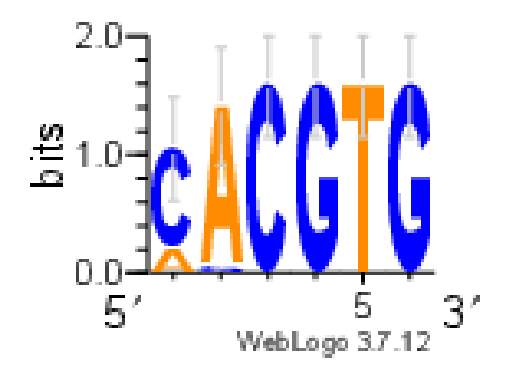

In [6]:
# Visualize Motif as Sequence Logo

# Import the necessary library for visualization
import matplotlib.pyplot as plt

# Generate a sequence logo for the motif
motif.weblogo("motif_logo.png")

# Display the generated sequence logo
img = plt.imread("motif_logo.png")
plt.imshow(img)
plt.axis('off')  # Hide the axes
plt.show()

# Calculate Information Content of a Motif
Calculate the information content of the motif.

In [7]:
# Calculate Information Content of a Motif

# Calculate the information content of the motif
information_content = motif.pssm.mean()

# Print the information content
print(f"Information Content: {information_content:.2f}")

Information Content: 10.99
